# Handwritten Digits Image Processing

# Data Loading

In [1]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()


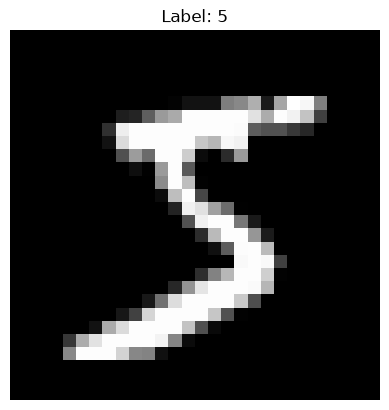

In [2]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

In [3]:
print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


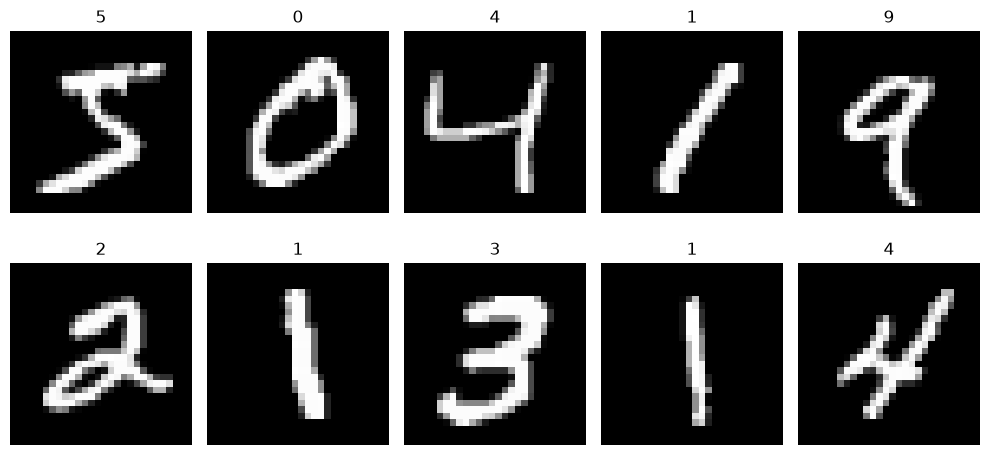

In [4]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

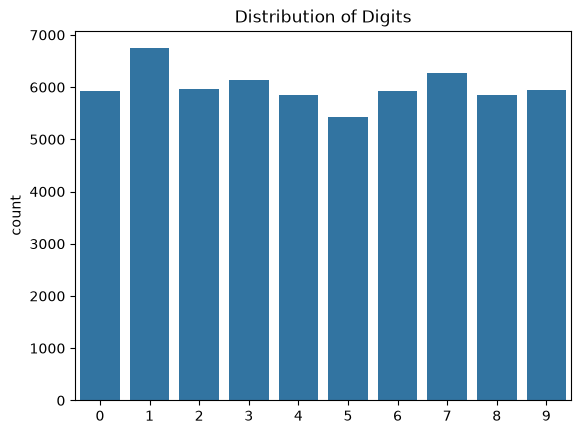

In [5]:
import seaborn as sns
import pandas as pd

sns.countplot(x=y_train)
plt.title("Distribution of Digits")
plt.show()


The MNIST dataset contains 60,000 training images and 10,000 testing images. Each image is a grayscale image of size 28×28 pixels. The target variable consists of 10 classes representing digits from 0 to 9. The class distribution is nearly balanced, making the dataset suitable for classification without requiring resampling techniques.

In [6]:
pd.Series(y_train).value_counts().sort_index()

0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

In [7]:
print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

Minimum Pixel Value: 0
Maximum Pixel Value: 255


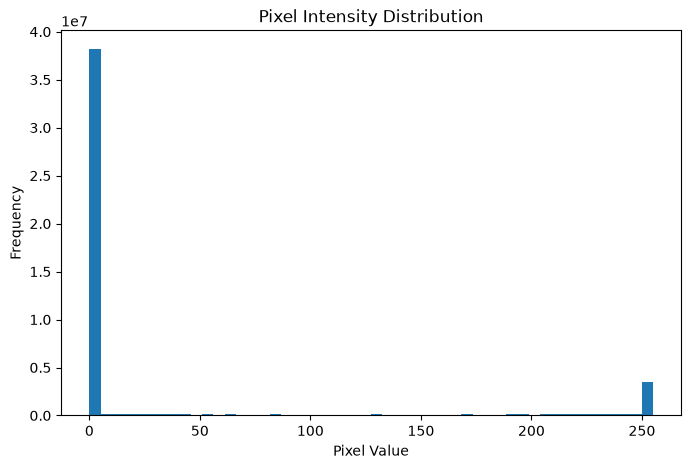

In [8]:
plt.figure(figsize=(8,5))
plt.hist(x_train.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

Pixel values range from 0 to 255. Most pixels are concentrated near 0 because the background of handwritten digit images is predominantly black.

In [9]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

In [10]:
x_train_flat = x_train_norm.reshape(60000, 784)
x_test_flat = x_test_norm.reshape(10000, 784)

In [11]:
print(x_train_norm.min())
print(x_train_norm.max())


0.0
1.0


### Data Analysis
1. The MNIST dataset contains 60,000 training images and 10,000 testing images.
2. Each image is a grayscale image of size 28×28 pixels.
3. The target variable consists of 10 classes representing digits from 0 to 9.
4. The dataset is nearly balanced across all classes.
5. Pixel values range from 0 to 255.
6. Most pixels have low intensity values because the background is predominantly black.

### Data Preprocessing
1. Images were normalized by dividing pixel values by 255.
2. Normalization scales values between 0 and 1.
3. Traditional machine learning models require 2D input, so each image was reshaped from 28×28 to a vector of 784 features.

# Model Training

## KNN

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(x_train_flat, y_train)

knn_pred = knn.predict(x_test_flat)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.9705


**K-Nearest Neighbors** 

achieved an accuracy of approximately 97% on the MNIST test dataset. The model performed well due to the similarity between handwritten digit images. However, KNN requires significant memory and prediction time because it stores all training samples and computes distances during inference.

## RANDOM FOREST

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train_flat, y_train)

rf_pred = rf.predict(x_test_flat)

rf_acc = accuracy_score(y_test, rf_pred)

print(rf_acc)

0.9704


**Random Forest Model Report**

Random Forest achieved an accuracy of **97%** on the MNIST dataset. The model uses multiple decision trees to improve prediction accuracy and reduce overfitting. It handled the high-dimensional image data effectively and produced stable results. However, it was slightly less suitable for image feature extraction compared to CNN.


## ANN

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

ann.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = ann.fit(
    x_train_norm,
    y_train_cat,
    epochs=10,
    validation_split=0.2
)

loss, ann_acc = ann.evaluate(
    x_test_norm,
    y_test_cat
)

print("ANN Accuracy:", ann_acc)

g:\Datamites\Projects_datamites\handwritten digit image processing\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9209 - loss: 0.2736 - val_accuracy: 0.9562 - val_loss: 0.1504
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9648 - loss: 0.1168 - val_accuracy: 0.9622 - val_loss: 0.1262
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9753 - loss: 0.0810 - val_accuracy: 0.9688 - val_loss: 0.1077
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9814 - loss: 0.0604 - val_accuracy: 0.9716 - val_loss: 0.1044
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9854 - loss: 0.0461 - val_accuracy: 0.9714 - val_loss: 0.1053
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9876 - loss: 0.0380 - val_accuracy: 0.9727 - val_loss: 0.1104
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9898 - loss: 0.0314 - val_accuracy: 0.9728 - val_loss: 0.1061
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9917 - loss: 0.0249 -

**ANN Model Report**

The Artificial Neural Network achieved an accuracy of **97%**. The model learned complex patterns from the pixel data using multiple dense layers. ANN performed well on the handwritten digit classification task but could not fully capture spatial image features. The model demonstrated good generalization and classification capability.


## CNN

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

x_train_cnn = x_train_norm.reshape(-1,28,28,1)
x_test_cnn = x_test_norm.reshape(-1,28,28,1)

cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    x_train_cnn,
    y_train_cat,
    epochs=5,
    validation_split=0.2
)

cnn_acc = cnn.evaluate(
    x_test_cnn,
    y_test_cat
)[1]

print("CNN Accuracy:", cnn_acc)

g:\Datamites\Projects_datamites\handwritten digit image processing\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9473 - loss: 0.1701 - val_accuracy: 0.9814 - val_loss: 0.0630
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9836 - loss: 0.0534 - val_accuracy: 0.9841 - val_loss: 0.0497
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9881 - loss: 0.0368 - val_accuracy: 0.9854 - val_loss: 0.0497
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9916 - loss: 0.0265 - val_accuracy: 0.9874 - val_loss: 0.0421
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.9931 - loss: 0.0208 - val_accuracy: 0.9872 - val_loss: 0.0436
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9897 - loss: 0.0338
CNN Accuracy: 0.9897000193595886


In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cnn_pred = cnn.predict(x_test_cnn)
cnn_pred_classes = np.argmax(cnn_pred, axis=1)

print(classification_report(y_test, cnn_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.97      0.99       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



**CNN Model Report**

The Convolutional Neural Network achieved the highest accuracy of 98% among all models. CNN automatically extracted important image features through convolution and pooling operations. It performed better than KNN, Random Forest, and ANN in recognizing handwritten digits. Therefore, CNN was selected as the best model for production deployment.

In [17]:
print("KNN Accuracy:", knn_acc)
print("Random Forest Accuracy:", rf_acc)
print("ANN Accuracy:", ann_acc)
print("CNN Accuracy:", cnn_acc)

KNN Accuracy: 0.9705
Random Forest Accuracy: 0.9704
ANN Accuracy: 0.9782999753952026
CNN Accuracy: 0.9897000193595886


### **Model Comparison Report**

Four models were trained and evaluated on the MNIST dataset. 

KNN, Random Forest, and ANN achieved an accuracy of 97%,while CNN achieved the highest accuracy of 98%. 

CNN performed better because it can automatically extract important image features using convolutional layers. 

Based on the overall performance and accuracy, CNN is recommended as the best model for production deployment.


### **Challenges Faced Report**

One challenge was handling high-dimensional image data, as each image contains 784 pixel values. 

This was addressed by normalizing the pixel values to improve model performance. 

Another challenge was distinguishing between visually similar digits such as 3 and 5 or 4 and 9. 

CNN was used to overcome this issue because it can learn image features more effectively than traditional machine learning models. 

Training time was also a challenge for some algorithms, so efficient models were selected for comparison.
